# **Clasificación de Emociones Caninas con InceptionV3**
### Trabajo Práctico Final IIA - Opción 4: Fine-Tuning
#### Santiago Bussanich, Tomás Castagnino, Gaspar Giménez

**Objetivo:** Desarrollar un sistema capaz de clasificar el estado emocional de un perro
a partir de imágenes utilizando Transfer Learning y Fine-Tuning sobre la arquitectura de InceptionV3.

**Motivación**
* Aprovechar modelos preentrenados para tareas de visión por computadora.
* Analizar la capacidad de adaptación de InceptionV3 a un dominio específico.
* Construir una aplicación sencilla que permita monitorear el estado emocional de una mascota mediante una cámara.

**Resultado esperado**: Clasificación automática de emociones caninas en tiempo real.

[Data set elegido](https://www.kaggle.com/datasets/danielshanbalico/dog-emotion)


Usaremos [esta](https://www.kaggle.com/code/yasserh/inception-v3-implementation) guía de implementación para el uso de InceptionV3.

Dos detalles a notar de InceptionV3:

| Detalle           | Valor                           | Por qué                                                                                                                          |
| ----------------- | ------------------------------- | -------------------------------------------------------------------------------------------------------------------------------- |
| Tamaño de entrada | 299×299 px                      | InceptionV3 fue diseñada para ese tamaño (otras redes usan 224).                                                                 |
| Preprocesado      | `inception_v3.preprocess_input` | Escala los píxeles al rango `[-1, 1]`, que es como la red vio ImageNet. Si le pasás `[0,255]` o `[0,1]`, predice cualquier cosa. |

Links útiles que vamos anotando:


*   [Keras documentation](https://keras.io/api/utils/)
    1.   En particular, [carga de imágenes](https://keras.io/api/data_loading/image/)
    2.   [Ejemplo de uso Keras para clasificación de imágenes](https://keras.io/keras_hub/guides/classification_with_keras_hub/)
    3.   [Guía de Keras para transfer learning (AUTOTUNE)](https://keras.io/guides/transfer_learning/): ejemplo de

    ```python
    train_ds = train_ds.batch(batch_size).prefetch(tf_data.AUTOTUNE).cache()
    validation_ds = validation_ds.batch(batch_size).prefetch(tf_data.AUTOTUNE).cache()
    test_ds = test_ds.batch(batch_size).prefetch(tf_data.AUTOTUNE).cache()
    ```

    4. [InceptionV3 con Keras](https://keras.io/api/applications/inceptionv3/)

    5. [Prepocesamiento con Incpetion](https://keras.io/api/applications/inceptionv3/inception_v3_preprocessing/): en particular vamos a usar la funcion preprocess_input que escala a [-1,1] un input x.



*   [Repo Github](https://github.com/gaspigz/TP-FINAL-IIA)


# **Sección 1: Set Up general**

En esta parte installamos las librerias que necesitamos e importamos todas las librerias de Python que vamos a usar.

In [1]:
!pip install tensorflow==2.21.0 keras==3.15.0 kagglehub==1.0.2 pandas==3.0.3 numpy==2.5.0 pillow==12.2.0 scikit-learn==1.9.0 matplotlib==3.11.0 seaborn==0.13.2 opencv-python==4.13.0.92

In [2]:
# Imports generales
import os
import keras
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications.inception_v3 import preprocess_input

from keras import layers


In [3]:
import sys, tensorflow as tf
print("python:", sys.executable)
print("GPU:", tf.config.list_physical_devices("GPU"))

python: /Users/gaspargimenez/Desktop/LCC/TP Final IIA/.venv/bin/python
GPU: []


# **Sección 2: Dataset**

Importamos el dataset de Kaggle, verificamos que lo hayamos descargado bien y despues normalizamos el dataset para poder usarlo con InnceptionV3.

Cuando quisimos procesar el dataset como veniamos haciendo en los tp anteriores (en forma de array) nos paso que google colab se nos quedaba sin RAM porque ahora las fotos son de 299x299x3, a diferencia de CIFAR10 que eran 32x32x3. Asi que trabajamos las imagenes con funciones la funcion shuffel para "mezclar" las imagenes y con .take y .skip para separar el dataset.

In [4]:
# Credenciales de Kaggle + descarga del dataset.
# Funciona en Google Colab y en local sin cambios: detecta el entorno automaticamente.
try:
    # las credenciales se leen desde los secrets de colab
    # Hay que cargar dos secrets: KAGGLE_USERNAME y KAGGLE_KEY.
    from google.colab import userdata
    os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
    os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")
    print("Entorno detectado: Google Colab (credenciales desde Secrets)")
except ImportError:
    # Local: leer kaggle.json desde la raiz del proyecto (junto a requirements.txt)
    # El archivo esta ignorado por git (.gitignore)
    import json
    cred_path = os.path.join(os.getcwd(), "kaggle.json")
    with open(cred_path) as f:
        creds = json.load(f)
    os.environ["KAGGLE_USERNAME"] = creds["username"]
    os.environ["KAGGLE_KEY"] = creds["key"]
    print(f"Entorno detectado: local (credenciales desde {cred_path})")

path = kagglehub.dataset_download("danielshanbalico/dog-emotion")
print("Dataset en:", path)

Entorno detectado: local (credenciales desde /Users/gaspargimenez/Desktop/LCC/TP Final IIA/kaggle.json)
Dataset en: /Users/gaspargimenez/.cache/kagglehub/datasets/danielshanbalico/dog-emotion/versions/1


In [5]:
# Explroemos la estructura de archivos
# Sirve para poder verificar que estan los archivos cargados
for root, dirs, files in os.walk(path):
    nivel = root.replace(path, "").count(os.sep)
    print("  " * nivel, os.path.basename(root), f"({len(files)} archivos)")
    for f in files[:2]:
        print("  " * (nivel + 1), "•", f)

 1 (0 archivos)
   Dog Emotion (1 archivos)
     • labels.csv
     happy (1000 archivos)
       • Q9qtGV4CptCUzjl71ndYO38SOm4sAN183.jpg
       • jTmqUHz9vbTH4UxDr2B8WYoCH5r8PO592.jpg
     sad (1000 archivos)
       • 9cwsljcV9ub5XTiJk3ZB2d9j5grPkb13.jpg
       • wSN8dYitT53GaqgmcAqojMmbkB7o6B958.jpg
     angry (1000 archivos)
       • LRg3BbSvwI1brnQBRXw6VfMe3DOoD8207.jpg
       • M92CKIVholYoryLvOXCNI44gxywTIQ141.jpg
     relaxed (1000 archivos)
       • L31eX21y0IBYVxUsmhf2kwCWha5tc2914.jpg
       • DsThuVNstNlyOmEH9BPYOhW1EN4DxS906.jpg


In [6]:
# Leer y mostrar el archivo CSV
csv_path = os.path.join(path, "Dog Emotion", "labels.csv")
df = pd.read_csv(csv_path)

# Mostrar las primeras filas del DataFrame
df.head()

,Unnamed: 0,filename,label
0,0,yubL63eiiPmoRru8Z2K2yRo0NnGDCL683.jpg,sad
1,1,c1tVljKiLM9q2zTBuQGWpxmzBuSeBR437.jpg,sad
2,2,RbzNOvY5GIAl3PSjIRTKpEkQs1NByq575.jpg,angry
3,3,gKujaBuWYezz0yWK9ydTFVi6LbQtXe397.jpg,angry
4,4,U0hJ2ryOu1IOuYpc01O7RngPYa8Xvz795.jpg,relaxed


#### A continuación construiremos el dataset y dividiremos en los tres conjuntos que nos interesan, algunos comentarios a tener en cuenta del código:

- Se definen algunos parámetros globales para el preprocesado como el tamaño de entrada esperado, el tamaño de batch, la semilla
- Se uso un $60$% de datos para entrenamiento, un $20$% para validación y un $20$% para test. Respecto a este split es importante aclarar que se hace sobre los paths de las imagenes ya decodificadas, lo que evita cargar las 4000 imágenes en memoria solo para dividirlas.
- Se uso una función para normalizar y redimensionar las imágenes al estándar de InceptionV3
- Se utilizó la macro AUTOTUNE, que permitió aplicar la función anterior en paralelo y almacenar los resultados en la caché del disco (más info de AUTOTUNE al final de este bloque).
- Respecto al shuffle, se aplica primero en el orden de los archivos (sobre los strings), y luego sobre el buffer por épocas (con las imágenes ya cacheadas).

> AUTOTUNE indica que la decodificación y el preprocesado se realizan una única vez durante la primera época y se reutilizan en las siguientes, acelerando significativamente el entrenamiento.

In [7]:
import pathlib
from sklearn.model_selection import train_test_split

IMG_SIZE = (299, 299)   # InceptionV3 espera 299x299
BATCH = 32
AUTOTUNE = tf.data.AUTOTUNE
SEED = 42

data_dir = os.path.join(path, "Dog Emotion")

class_names = {0: "angry", 1: "happy", 2: "relaxed", 3: "sad"}
num_classes = len(class_names)
CLASES = [class_names[i] for i in range(num_classes)]   # orden alfabético = carpetas

# --- Split determinista y estratificado sobre la LISTA DE ARCHIVOS ----------------
# Hacer el split sobre los archivos (y NO sobre un dataset ya decodificado) evita
# re-decodificar las 4000 imágenes en cada época, que era lo que volvía todo lentísimo.
def _listar_archivos(data_dir, clases=CLASES):
    paths, labels = [], []
    for idx, cls in enumerate(clases):
        for f in sorted(pathlib.Path(data_dir, cls).glob("*")):
            if f.suffix.lower() in {".jpg", ".jpeg", ".png"}:
                paths.append(str(f)); labels.append(idx)
    return np.array(paths), np.array(labels)

paths_all, labels_all = _listar_archivos(data_dir)

# 60% train / 20% val / 20% test, manteniendo el balance de clases
p_tmp, p_test, y_tmp, y_test = train_test_split(
    paths_all, labels_all, test_size=0.20, stratify=labels_all, random_state=SEED)
p_train, p_val, y_train, y_val = train_test_split(
    p_tmp, y_tmp, test_size=0.25, stratify=y_tmp, random_state=SEED)   # 0.25*0.8 = 0.2

# --- Carga + preprocesado, con CACHE en disco ANTES del shuffle/batch -------------
def _cargar(p, y):
    img = tf.io.read_file(p)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = preprocess_input(img)          # InceptionV3: [-1, 1]
    return img, y

def _arma_ds(paths, labels, cache_file, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        # mezcla el ORDEN DE ARCHIVOS una sola vez (barato: son strings, sin decodificar)
        ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=False)
    ds = ds.map(_cargar, num_parallel_calls=AUTOTUNE)
    ds = ds.cache(cache_file)            # se llena UNA vez (1ra época) y se reusa
    if shuffle:
        # variación por época con poca RAM (~0.5 GB de buffer, no las 4000 imágenes)
        ds = ds.shuffle(512, seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(BATCH).prefetch(AUTOTUNE)

train_ds = _arma_ds(p_train, y_train, "/tmp/tp_train", shuffle=True)
val_ds   = _arma_ds(p_val,   y_val,   "/tmp/tp_val")
test_ds  = _arma_ds(p_test,  y_test,  "/tmp/tp_test")

print("Clases:", CLASES)
print(f"train: {len(p_train)} | val: {len(p_val)} | test: {len(p_test)} imágenes")

Clases: ['angry', 'happy', 'relaxed', 'sad']
train: 2400 | val: 800 | test: 800 imágenes


W0000 00:00:1782855524.126624 10184570 cache_dataset_ops.cc:330] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


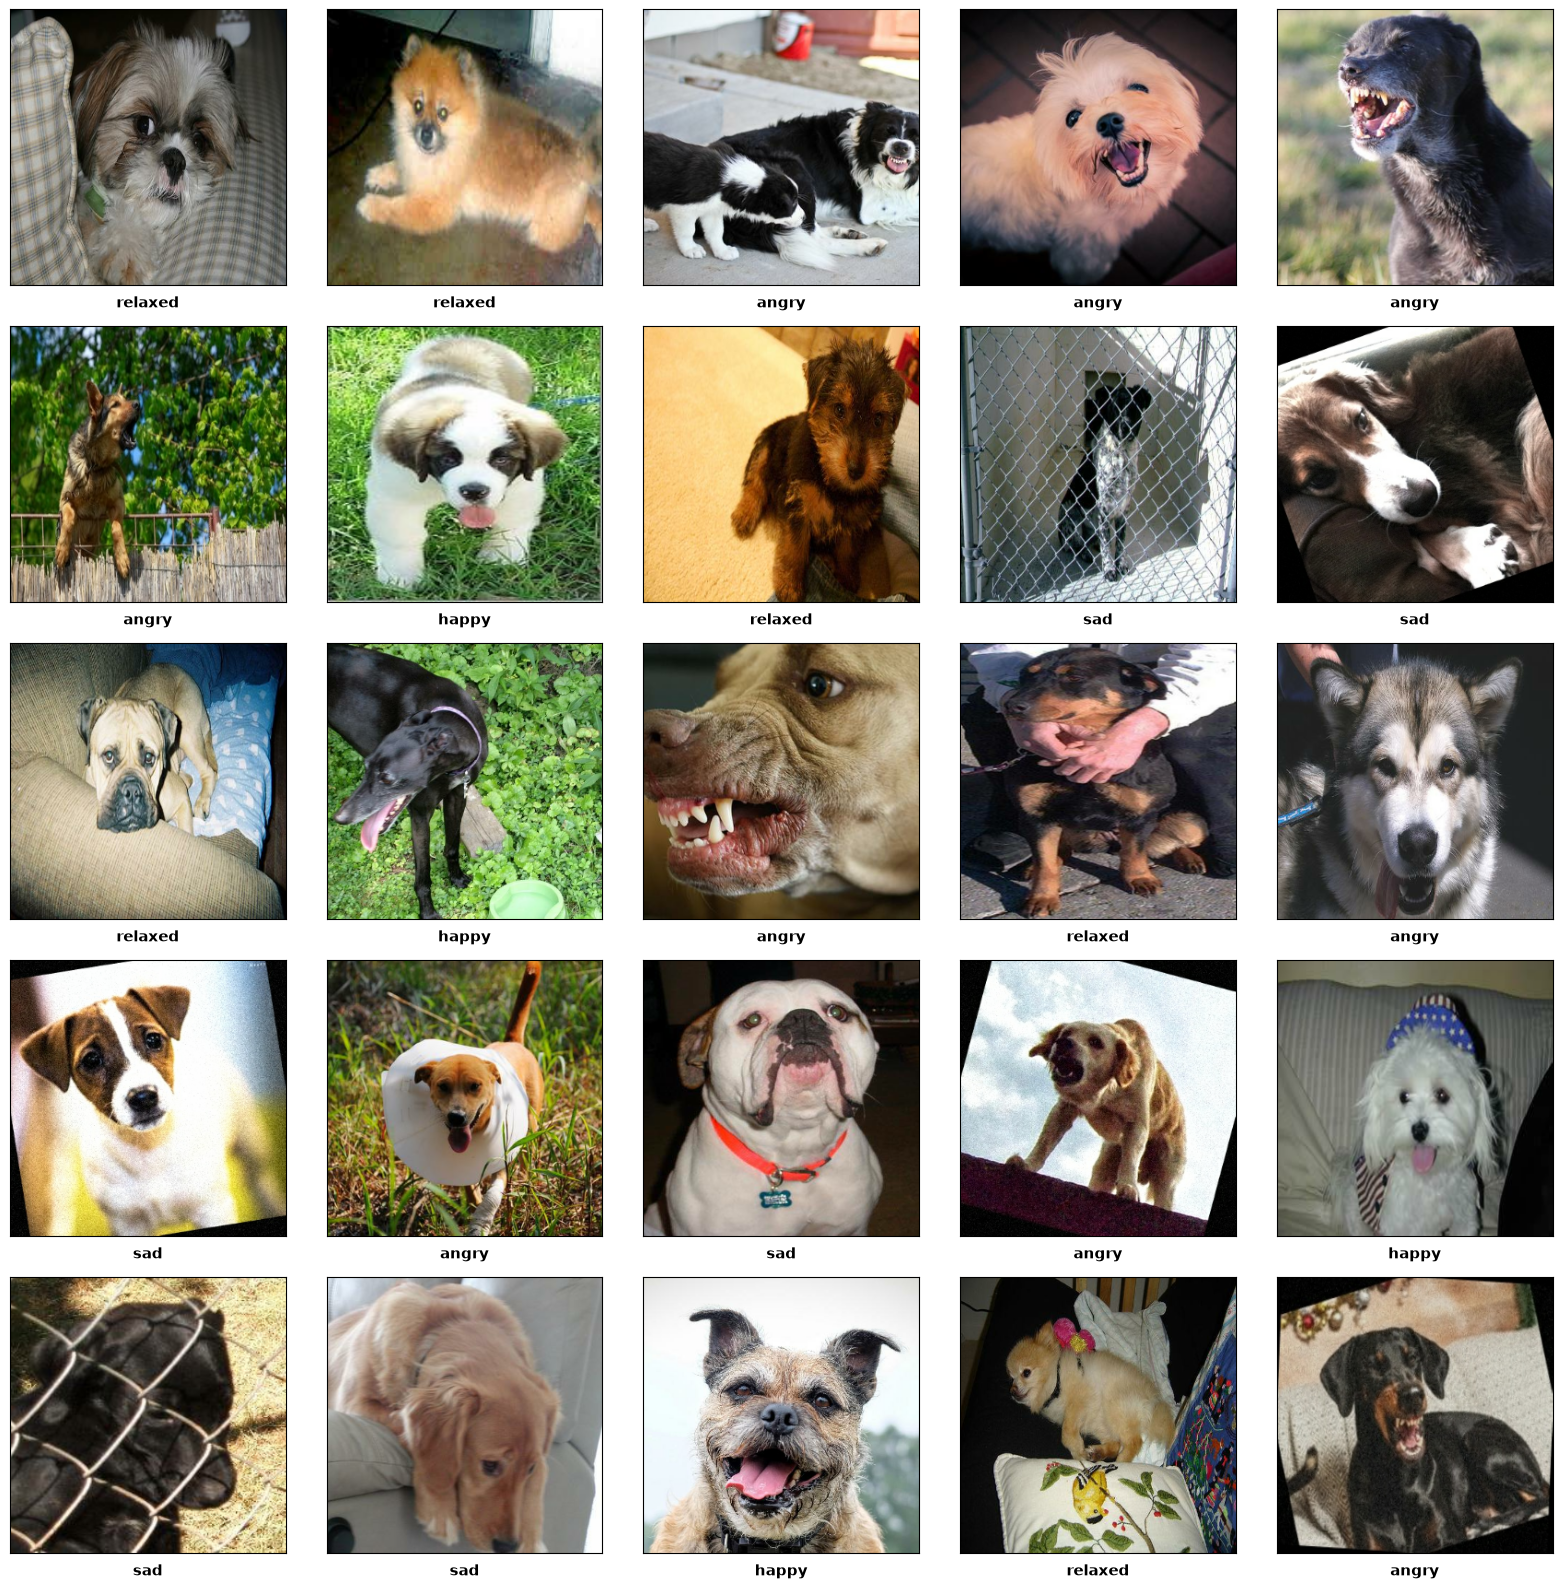

In [8]:
# Printeamos 25 imagenes de distintos baches para verificar que se ven.
images_list, labels_list = [], []

def denormalize(img):
    return (img + 1) / 2  # [-1,1] → [0,1]

for images_batch, labels_batch in train_ds.take(1):
    for img, label in zip(images_batch, labels_batch):
        images_list.append(img.numpy())
        labels_list.append(label.numpy())
        if len(images_list) == 25:
            break
    if len(images_list) == 25:
        break

# Visualizar (como arriba)
fig, axes = plt.subplots(5, 5, figsize=(16, 16))
axes = axes.flatten()

for idx in range(25):
    image = denormalize(images_list[idx])
    label_name = class_names[labels_list[idx]]

    axes[idx].imshow(image)
    axes[idx].set_xlabel(label_name, fontsize=11, fontweight='bold', labelpad=8)
    axes[idx].set_xticks([])
    axes[idx].set_yticks([])

plt.tight_layout()
plt.show()

# **Sección 3: Crear modelo**

### **3.1: Investigación sobre el funcionamiento de InceptionV3**

La idea es hacer dos cosas, ANTES de inception meter el data augmentation, y luego del inception meter el nuevo clasificador.

Inception originalmente es algo como esto:

```
Imagen
InceptionV3
GlobalAveragePooling
Dense(1000)
1000 clases ImageNet
```



Por el include_top=False queda la estructura:



```
Imagen
InceptionV3
falta el clasificador
```



#### Algunas notas obrenidas de la docu de [keras](https://keras.io/guides/transfer_learning/):

**Freezing layers**: understanding the trainable attribute

**Layers & models have three weight attributes:**

- weights is the list of all weights variables of the layer.

- trainable_weights is the list of those that are meant to be updated (via gradient descent) to minimize the loss during training.

- non_trainable_weights is the list of those that aren't meant to be trained. Typically they are updated by the model during the forward pass.

**Si hacemos a una capa entrenable, le podemos aplicar fine tuning.**

Para congelar una capa entonces usamos:

```python
layer.trainable = False
```



### **3.2: Preprocesado del dataset**
Veamos como funciona este preprocesado

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.910249..1.0].


Archivo: /Users/gaspargimenez/.cache/kagglehub/datasets/danielshanbalico/dog-emotion/versions/1/Dog Emotion/angry/qtJ1jgFyoWZnowRo0MNAJnkoIi1wcr35.jpg
Original     -> min: 11.443251609802246 max: 255.0
Preprocesada -> min: -0.9102489948272705 max: 1.0


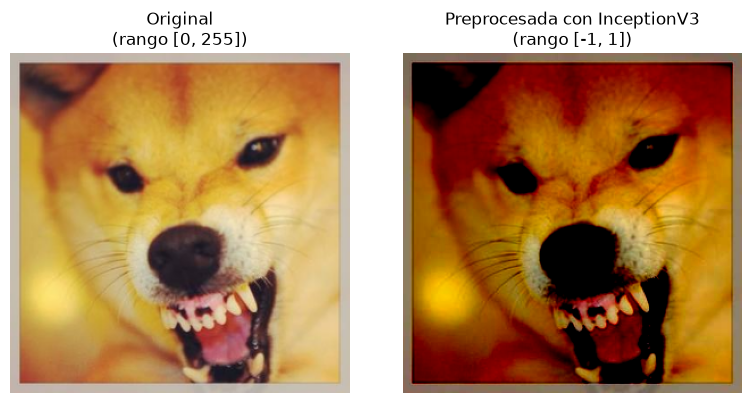

In [12]:
# Visualizamos el preprocesado de InceptionV3 sobre una FOTO ALEATORIA del dataset.
# (El pipeline ya entrega las imágenes preprocesadas en [-1, 1]; acá partimos de un
#  archivo crudo para ver el efecto del preprocesado a mano.)
import random

ruta = random.choice(paths_all)
raw = tf.io.read_file(ruta)
img = tf.io.decode_image(raw, channels=3, expand_animations=False)
img = tf.image.resize(img, IMG_SIZE)

img_pre = keras.applications.inception_v3.preprocess_input(tf.identity(img))

print("Archivo:", ruta)
print("Original     -> min:", float(tf.reduce_min(img)),     "max:", float(tf.reduce_max(img)))
print("Preprocesada -> min:", float(tf.reduce_min(img_pre)), "max:", float(tf.reduce_max(img_pre)))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Imagen original: valores uint8 [0, 255]
axes[0].imshow(img.numpy().astype("uint8"))
axes[0].set_title("Original\n(rango [0, 255])")
axes[0].axis("off")

# Imagen preprocesada: InceptionV3 mapea [0,255] -> [-1,1]
# matplotlib clipea valores negativos a negro, mostrando el efecto real del preprocesado.
axes[1].imshow(img_pre.numpy())
axes[1].set_title("Preprocesada con InceptionV3\n(rango [-1, 1])")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### **3.3 Auxiliar: Guardar y Cargar Modelos e Historias de Entrenamiento**

A continuación definimos funciones útiles para guardar el modelo y su historial de entrenamiento en disco (con soporte para descargarlo/cargarlo automáticamente si estás usando Google Colab).

In [8]:
import pickle
import os

def guardar_modelo_y_historial(model, history, base_name='modelo_inception_dogs'):
    """
    Guarda el modelo de Keras y su historial de entrenamiento en archivos.
    Soporta descarga automática si se ejecuta en Google Colab.
    """
    # Crear las carpetas si no existen (p. ej. al clonar el repo en limpio)
    os.makedirs("models", exist_ok=True)
    os.makedirs("histories", exist_ok=True)

    # Guardar el modelo. Usamos el nombre base tal como se solicita.
    model_path = f"models/{base_name}.keras"
    model.save(model_path)
    print(f"Modelo guardado exitosamente en: {model_path}")
    
    # Obtener el diccionario del historial y guardarlo con pickle
    history_dict = history.history if hasattr(history, 'history') else history
    history_path = f"histories/{base_name}_history.pkl"
    with open(history_path, 'wb') as f:
        pickle.dump(history_dict, f)
    print(f"Historial guardado exitosamente en: {history_path}")
    
    # Si estamos en Google Colab, descargamos los archivos automáticamente
    try:
        from google.colab import files
        # Si el modelo se guardó como carpeta (SavedModel sin extensión), se comprime para facilitar la descarga
        if os.path.isdir(model_path):
            import zipfile
            zip_path = f"{model_path}.zip"
            with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
                for root, dirs, files_in_dir in os.walk(model_path):
                    for file in files_in_dir:
                        zipf.write(os.path.join(root, file), 
                                   os.path.relpath(os.path.join(root, file), os.path.join(model_path, '..')))
            print(f"Modelo comprimido en {zip_path} para su descarga.")
            files.download(zip_path)
        else:
            files.download(model_path)
        files.download(history_path)
        print("Descargas iniciadas en Google Colab.")
    except ImportError:
        print("Entorno local detectado. Los archivos permanecen guardados en el disco local.")

In [9]:
from tensorflow.keras.models import load_model
import pickle
import os

def cargar_modelo_y_historial(base_name='modelo_inception_dogs'):
    """
    Permite subir archivos si se ejecuta en Google Colab y carga el modelo junto con su historial.
    """
    model_path = f"models/{base_name}.keras"
    history_path = f"histories/{base_name}_history.pkl"
    
    # Si estamos en Google Colab, solicita subir los archivos
    try:
        from google.colab import files
        print(f"Por favor, subí el modelo ({model_path}) y el historial ({history_path}):")
        uploaded = files.upload()
        # Si se subió un archivo zip (por haber guardado el modelo como carpeta)
        zip_path = f"{model_path}.zip"
        if zip_path in uploaded and not os.path.exists(model_path):
            import zipfile
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                zip_ref.extractall(".")
            print(f"Modelo descomprimido desde {zip_path}")
    except ImportError:
        print("Entorno local detectado. Cargando archivos directamente desde el directorio de trabajo.")
        
    # Cargar el modelo
    modelo_cargado = load_model(model_path)
    print(f"Modelo cargado exitosamente desde: {model_path}")
    
    # Cargar el historial
    with open(history_path, 'rb') as f:
        history_cargado = pickle.load(f)
    print(f"Historial cargado exitosamente desde: {history_path}")
    
    return modelo_cargado, history_cargado

# Ejemplo de uso (para cargar y hacer predicciones):
# modelo_recuperado, historial_recuperado = cargar_modelo_y_historial('modelo_inception_dogs')
# predicciones = modelo_recuperado.predict(test_ds)
# print("Predicciones realizadas de forma exitosa sobre test_ds.")

# **Sección 4: Modelo base para los experimentos**

#### El primer paso es encontrar cual es la mejor manera para obtener un **modelo base correcto**, a partir del cual podremos hacer experimentos y aplicar variaciones en su configuración, como puede ser dropout, data augmentation, etc. 

Este primer modelo base nos servirá para ir mutando, haciendo fine tuning y evaluando su performance.

Definimos `create_inception_model`, que arma InceptionV3 + cabeza nueva y permite:
- **descongelar las últimas N capas** del backbone (fine-tuning gradual),
- activar **data augmentation** y **dropout** (los usaremos en los datasets chicos).

> Esta versión corrige el bug del descongelado (`base_model.layers`, no `model.layers`) y
> redefine la función anterior al ejecutarse.

In [10]:
import re

def _inicio_ultimas_convs(base_model, n_convs):
    """Índice desde donde descongelar para liberar las últimas n_convs capas Conv2D."""
    if n_convs <= 0:
        return len(base_model.layers)
    contador = 0
    for i in range(len(base_model.layers) - 1, -1, -1):   # de atrás hacia adelante
        if isinstance(base_model.layers[i], keras.layers.Conv2D):
            contador += 1
            if contador == n_convs:
                return i          # la conv n_convs-ésima desde el final
    return 0                      # n_convs >= total -> descongela todo


def _inicio_ultimos_bloques(base_model, n_bloques):
    """Índice de capa desde donde descongelar para liberar los últimos n_bloques inception."""
    # mixed0..mixed10 son los puntos de concatenación de cada bloque (no matchea 'mixed9_0')
    mixed = [i for i, l in enumerate(base_model.layers) if re.fullmatch(r"mixed\d+", l.name)]
    if n_bloques <= 0:
        return len(base_model.layers)        # no descongela nada
    if n_bloques >= len(mixed):
        return 0                             # descongela todo el backbone
    # arrancamos justo DESPUÉS del mixed que queda n_bloques antes del final:
    # las convs de un bloque están entre su mixed anterior y su propio mixed.
    print(f'Cantidad de capas al descongelar {n_bloques}: {mixed[-(n_bloques + 1)] + 1}')
    return mixed[-(n_bloques + 1)] + 1


def create_inception_model(num_classes=4, augment=False, dropout=0.0,
                           n_convs_descongeladas=0,
                           n_bloques_descongelados=0,
                           cantidad_capas_descongeladas=0):
    """
    InceptionV3 + cabeza nueva. El descongelado se controla con UNO de estos argumentos
    (sin tocar las BatchNorm, que se dejan congeladas):
      - n_convs_descongeladas        -> últimas N capas Conv2D
      - n_bloques_descongelados      -> últimos N bloques inception (mixed)
      - cantidad_capas_descongeladas -> últimas N capas (compatibilidad con Exp 2)
    """
    base_model = keras.applications.InceptionV3(
        include_top=False, weights="imagenet", input_shape=(299, 299, 3))
    base_model.trainable = False

    inputs = keras.Input(shape=(299, 299, 3))
    x = inputs
    if augment:
        x = layers.RandomFlip("horizontal")(x)
        x = layers.RandomRotation(0.1)(x)
        x = layers.RandomZoom(0.1)(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    if dropout and dropout > 0:
        x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="output")(x)
    model = keras.Model(inputs, outputs, name="inceptionV3_dog_emotion")

    inicio = None
    if n_convs_descongeladas > 0:
        inicio = _inicio_ultimas_convs(base_model, n_convs_descongeladas)
    elif n_bloques_descongelados > 0:
        inicio = _inicio_ultimos_bloques(base_model, n_bloques_descongelados)
    elif cantidad_capas_descongeladas > 0:
        inicio = len(base_model.layers) - cantidad_capas_descongeladas

    if inicio is not None:
        base_model.trainable = True
        for layer in base_model.layers[:inicio]:
            layer.trainable = False
        for layer in base_model.layers[inicio:]:
            if not isinstance(layer, keras.layers.BatchNormalization):
                layer.trainable = True
    return model

## Utilidades de evaluación

Funciones reutilizables para evaluar cualquier modelo:
- `predicciones`: corre el modelo sobre un dataset y devuelve etiquetas reales vs predichas.
- `plot_matriz_confusion`: dibuja la matriz de confusión (coloreada por proporción, anotada
  con conteos) e imprime el `classification_report` (precision / recall / f1 por clase).

In [11]:
from sklearn.metrics import confusion_matrix, classification_report

CLASES = ["angry", "happy", "relaxed", "sad"]   # orden de full_ds.class_names

def predicciones(model, ds):
    y_true = np.concatenate([y.numpy() for _, y in ds])
    y_pred = np.argmax(model.predict(ds, verbose=0), axis=1)
    return y_true, y_pred

def plot_matriz_confusion(y_true, y_pred, titulo, clases=CLASES):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(clases)))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    plt.figure(figsize=(5.5, 4.5))
    sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues", vmin=0, vmax=1,
                xticklabels=clases, yticklabels=clases)
    plt.xlabel("Predicho"); plt.ylabel("Real"); plt.title(titulo)
    plt.tight_layout(); plt.show()
    print(classification_report(y_true, y_pred, target_names=clases, digits=3))

In [12]:
import time, glob, re
import pandas as pd

CONFIGS_DESCONGELADO = [0, 10, 30, 50, 100]   # InceptionV3 tiene 311 capas
EPOCHS_EXP1, PATIENCE_EXP1 = 40, 6

QUIERO_REENTRENAR = False

def _indices_existentes(base):
    """Devuelve los índices (ordenados) de los archivos base_<n>.keras ya guardados."""
    idxs = []
    for f in glob.glob(f"models/{base}_*.keras"):
        m = re.search(re.escape(base) + r"_(\d+)\.keras$", f)
        if m:
            idxs.append(int(m.group(1)))
    return sorted(idxs)


In [13]:
def entrenar_config(n_desc, train_ds, val_ds, *, modo="convs", augment=False, dropout=0.0,
                    lr=None, epochs=EPOCHS_EXP1, patience=PATIENCE_EXP1,
                    usar_early_stopping=False, verbose=1):
    """Entrena un modelo y devuelve (modelo, history_dict). No guarda nada.

    `modo` define cómo se descongela el backbone:
      - "capas"   -> últimas n_desc capas
      - "bloques" -> últimos n_desc bloques inception
      - "convs"   -> últimas n_desc capas Conv2D
    """
    keras.backend.clear_session()
    if lr is None:                       # LR alto para la cabeza, bajo para fine-tuning
        lr = 1e-3 if n_desc == 0 else 1e-4
    arg = {"capas": "cantidad_capas_descongeladas",
           "bloques": "n_bloques_descongelados",
           "convs": "n_convs_descongeladas"}[modo]
    model = create_inception_model(num_classes=4, augment=augment, dropout=dropout,
                                   **{arg: n_desc})
    model.compile(optimizer=keras.optimizers.Adam(lr),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    cb = []
    if usar_early_stopping:
        cb.append(keras.callbacks.EarlyStopping(monitor="val_accuracy",
                                                patience=patience, restore_best_weights=True))
    hist = model.fit(train_ds, validation_data=val_ds, epochs=epochs,
                     callbacks=cb, verbose=verbose)
    return model, hist.history

In [14]:
def resultado(model, history, n_desc, test_ds, segundos=None):
    """Arma el dict de resultados (recalcula test/predicciones desde el modelo)."""
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    y_true, y_pred = predicciones(model, test_ds)
    params = int(sum(tf.size(w).numpy() for w in model.trainable_weights))
    return {
        "n_descongeladas": n_desc, "params_entrenables": params,
        "best_val_acc": max(history["val_accuracy"]),
        "best_val_loss": min(history["val_loss"]),
        "epoca_min_val_loss": int(np.argmin(history["val_loss"])),
        "test_acc": float(test_acc), "test_loss": float(test_loss),
        "epocas_corridas": len(history["loss"]), "segundos": segundos,
        "history": history, "y_true": y_true, "y_pred": y_pred,
    }


def graficar_barrido(resultados, etiqueta="capas"):
    """Tabla + accuracy vs descongelamiento + curvas de loss por configuración."""
    from IPython.display import display
    df = pd.DataFrame([{k: v for k, v in r.items()
                        if k not in ("history", "y_true", "y_pred")} for r in resultados])
    display(df)

    # (a) accuracy final vs cantidad descongelada
    plt.figure(figsize=(9, 5))
    plt.plot(df["n_descongeladas"], df["best_val_acc"], "o-", label="val (mejor)")
    plt.plot(df["n_descongeladas"], df["test_acc"], "s-", label="test")
    plt.xlabel(f"{etiqueta.capitalize()} descongeladas"); plt.ylabel("Accuracy")
    plt.title(f"Accuracy vs {etiqueta} descongeladas"); plt.ylim(0.3, 0.9)
    plt.grid(True, alpha=.3); plt.legend(); plt.show()

    # (b) train vs val loss por configuración (línea = época de menor val_loss)
    n = len(resultados); cols = 3; rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 3.6 * rows), squeeze=False, sharey=True, sharex=True)
    for ax, r in zip(axes.flat, resultados):
        h = r["history"]
        ax.plot(h["loss"], label="train"); ax.plot(h["val_loss"], label="val")
        mejor = int(np.argmin(h["val_loss"])); ax.axvline(mejor, ls="--", c="gray", alpha=.7)
        ax.set_title(f'{r["n_descongeladas"]} {etiqueta} (min val_loss ép. {mejor})')
        ax.set_xlabel("época"); ax.set_ylabel("loss"); ax.grid(alpha=.3); ax.legend(fontsize=8)
    for ax in axes.flat[n:]:
        ax.axis("off")
    plt.tight_layout(); plt.show()
    return df

## **Sección 4.1: Primer enfoque - descongelamiento por capas**

Entrenamos un modelo **independiente por cada cantidad de capas descongeladas** y vemos cómo
progresa la accuracy a medida que liberamos más del backbone. Sin data augmentation (con 4000
imágenes balanceadas no hace falta). Cada modelo se guarda (`.keras` + historial) y guardamos
también sus predicciones sobre *test* para la matriz de confusión.

In [19]:
resultados_exp1 = []
for n in CONFIGS_DESCONGELADO:
    base = f"exp1_desc{n}"
    idxs = _indices_existentes(base)

    if idxs and not QUIERO_REENTRENAR:
        ult = idxs[-1]
        print(f"\n[{n} capas] Ya existe {base}_{ult}.keras -> CARGANDO (no entreno).")
        model, history = cargar_modelo_y_historial(f"{base}_{ult}")
        r = resultado(model, history, n, test_ds)
    else:
        nuevo = (idxs[-1] + 1) if idxs else 1
        accion = "RE-ENTRENANDO" if idxs else "ENTRENANDO"
        print(f"\n[{n} capas] {accion} -> se guardará como {base}_{nuevo}")
        t0 = time.time()
        model, history = entrenar_config(n, train_ds, val_ds, modo="capas", usar_early_stopping=False)
        seg = round(time.time() - t0, 1)
        guardar_modelo_y_historial(model, history, f"{base}_{nuevo}")
        r = resultado(model, history, n, test_ds, segundos=seg)

    resultados_exp1.append(r)
    del model
    keras.backend.clear_session()


[0 capas] Ya existe exp1_desc0_1.keras -> CARGANDO (no entreno).
Entorno local detectado. Cargando archivos directamente desde el directorio de trabajo.
Modelo cargado exitosamente desde: models/exp1_desc0_1.keras
Historial cargado exitosamente desde: histories/exp1_desc0_1_history.pkl


I0000 00:00:1782764189.209256    6128 service.cc:153] XLA service 0x7e28f8072ba0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782764189.209371    6128 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5060 Ti, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.2)
I0000 00:00:1782764189.336752    6128 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1782764190.005667    6128 cuda_dnn.cc:461] Loaded cuDNN version 92302
I0000 00:00:1782764201.812159    6128 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
W0000 00:00:1782764203.129045    6263 cache_dataset_ops.cc:330] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded


[10 capas] Ya existe exp1_desc10_1.keras -> CARGANDO (no entreno).
Entorno local detectado. Cargando archivos directamente desde el directorio de trabajo.
Modelo cargado exitosamente desde: models/exp1_desc10_1.keras
Historial cargado exitosamente desde: histories/exp1_desc10_1_history.pkl

[30 capas] Ya existe exp1_desc30_1.keras -> CARGANDO (no entreno).
Entorno local detectado. Cargando archivos directamente desde el directorio de trabajo.
Modelo cargado exitosamente desde: models/exp1_desc30_1.keras
Historial cargado exitosamente desde: histories/exp1_desc30_1_history.pkl

[50 capas] Ya existe exp1_desc50_1.keras -> CARGANDO (no entreno).
Entorno local detectado. Cargando archivos directamente desde el directorio de trabajo.
Modelo cargado exitosamente desde: models/exp1_desc50_1.keras
Historial cargado exitosamente desde: histories/exp1_desc50_1_history.pkl

[100 capas] Ya existe exp1_desc100_1.keras -> CARGANDO (no entreno).
Entorno local detectado. Cargando archivos directament

### Exp 1 — Tabla resumen

Resultados por configuración: parámetros entrenables, mejor accuracy de validación, accuracy
en *test*, épocas efectivas (corta el EarlyStopping) y tiempo.

In [20]:
df_exp1 = pd.DataFrame([{k: v for k, v in r.items()
                         if k not in ("history", "y_true", "y_pred")}
                        for r in resultados_exp1])
df_exp1

,n_descongeladas,params_entrenables,best_val_acc,best_val_loss,epoca_min_val_loss,test_acc,test_loss,epocas_corridas,segundos
0,0,8196,0.69125,0.774400,27,0.66000,0.873736,40,None
1,10,8196,0.65750,0.879116,39,0.63875,0.915385,40,None
2,30,5160964,0.75250,0.668524,2,0.74875,1.215930,40,None
3,50,7176196,0.79625,0.585634,1,0.77250,1.338560,40,None
4,100,13623300,0.84625,0.509144,1,0.81625,1.176483,40,None


### Exp 1 — Gráficos

(a) Accuracy final (val y test) **vs** cantidad de capas descongeladas.
(b) Curvas de `val_accuracy` y `val_loss` por época, una por configuración.

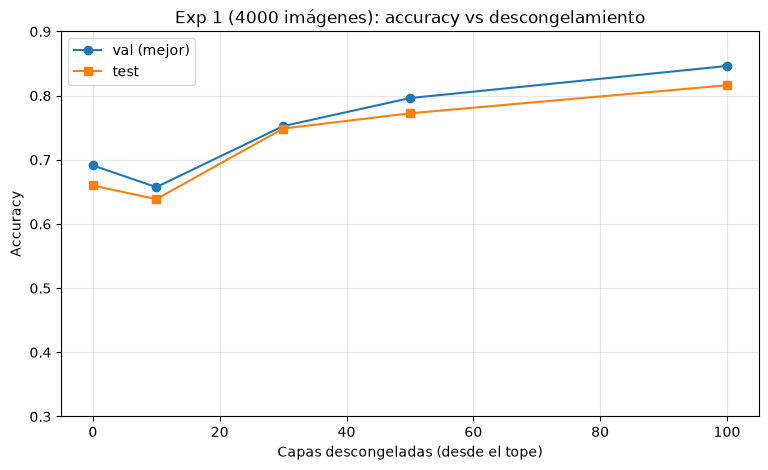

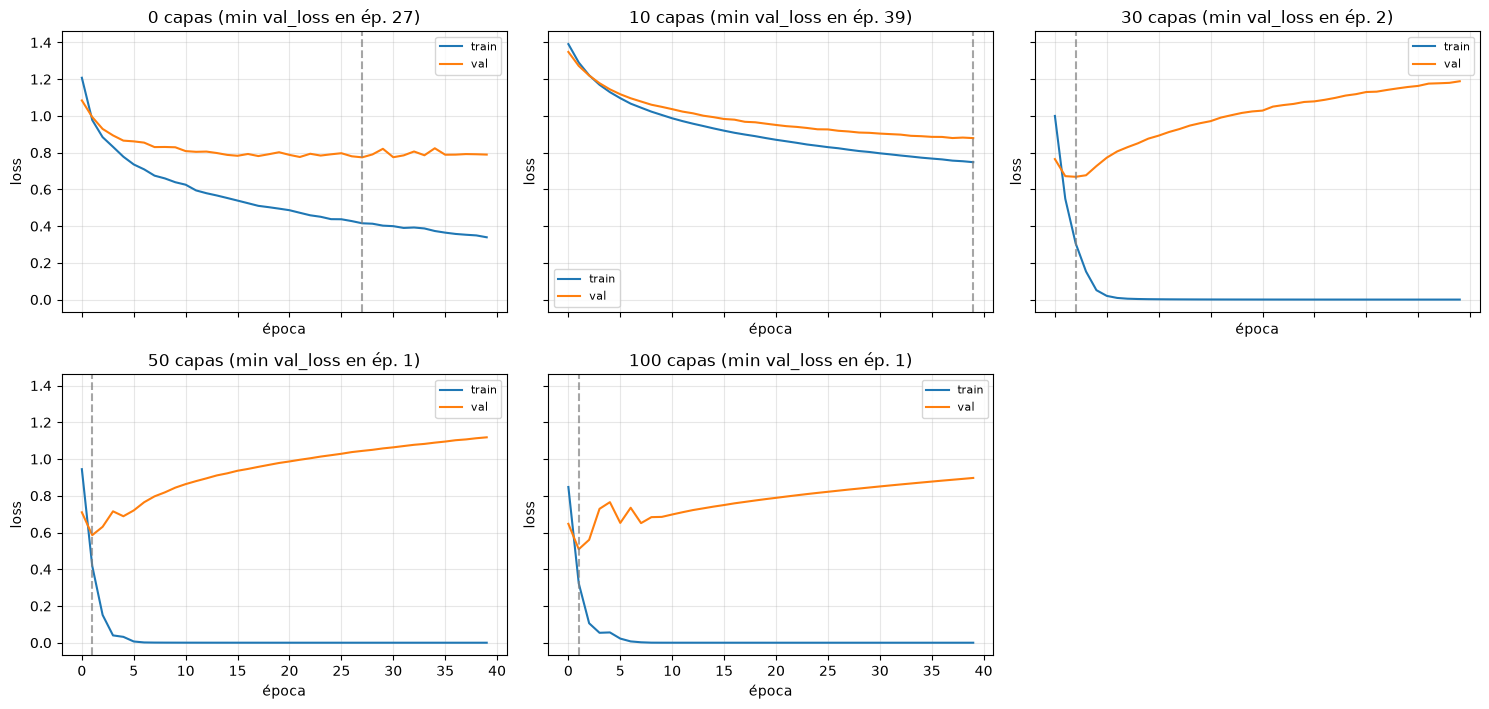

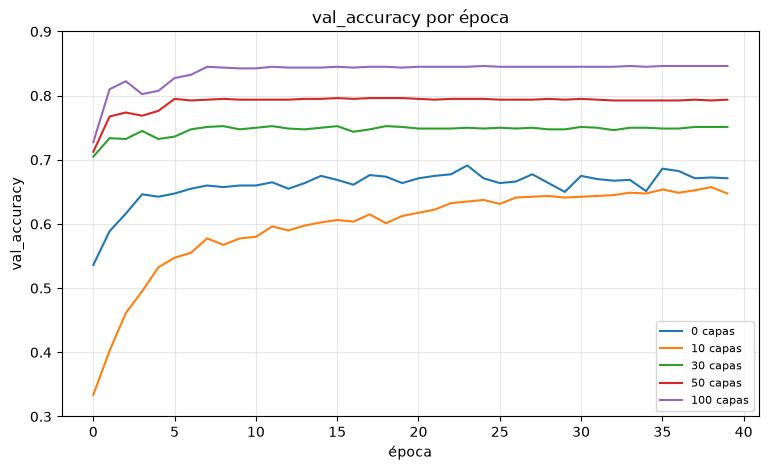

In [21]:
# (a) Accuracy final (val/test) vs capas descongeladas
plt.figure(figsize=(9, 5))
plt.plot(df_exp1["n_descongeladas"], df_exp1["best_val_acc"], "o-", label="val (mejor)")
plt.plot(df_exp1["n_descongeladas"], df_exp1["test_acc"], "s-", label="test")
plt.xlabel("Capas descongeladas (desde el tope)"); plt.ylabel("Accuracy")
plt.title("Exp 1 (4000 imágenes): accuracy vs descongelamiento"); plt.ylim(0.3, 0.9)
plt.grid(True, alpha=.3); plt.legend(); plt.show()

# (b) train vs val LOSS por configuración -> para ver CUÁNDO empieza el overfitting.
#     La línea punteada marca la época de menor val_loss (punto ideal de early stopping).
n = len(resultados_exp1)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 3.6 * rows), squeeze=False, sharey=True, sharex=True)
for ax, r in zip(axes.flat, resultados_exp1):
    h = r["history"]
    ax.plot(h["loss"], label="train")
    ax.plot(h["val_loss"], label="val")
    mejor = int(np.argmin(h["val_loss"]))
    ax.axvline(mejor, ls="--", c="gray", alpha=.7)
    ax.set_title(f'{r["n_descongeladas"]} capas (min val_loss en ép. {mejor})')
    ax.set_xlabel("época"); ax.set_ylabel("loss"); ax.grid(alpha=.3); ax.legend(fontsize=8)
for ax in axes.flat[n:]:
    ax.axis("off")
plt.tight_layout(); plt.show()

# (c) val_accuracy por época (todas las configuraciones juntas)
plt.figure(figsize=(9, 5))
for r in resultados_exp1:
    plt.plot(r["history"]["val_accuracy"], label=f'{r["n_descongeladas"]} capas')
plt.title("val_accuracy por época"); plt.xlabel("época"); plt.ylabel("val_accuracy"); plt.ylim(0.3, 0.9)
plt.grid(alpha=.3); plt.legend(fontsize=8); plt.show()

### Conclusiones 4.1

Notemos que descongelando 0 y 10 capas obtenemos los mismos resultados (los parámetros entrenables son 8196), esto se debe a que en InceptionV3 tiene entre sus últimas 10 capas sólo una entrenable, el resto como se ve en print superior no son entrenables.

## **Sección 4.2: Segundo enfoque - descongelamiento por bloques Inception**
A partir de ahora haremos descongelamiento por **bloques inception**, en particular con cero, uno y dos bloques, pues vimos también que a partir de las 30 capas descongeladas hay overfitting por lo que no creemos que valga la pena hacer un análisis más allá. Cada bloque inception refiere a una capa densa dentro del modelo.

Para calcular la lognitud de los bloques inception (cantidad de capas), usamos la siguiente funcion y modificamos `create_inception_model`:

In [16]:
QUIERO_REENTRENAR_BLOQUES = True

#### Este código nos ayuda a ver la relación capas-bloques y cuantos parámetros entrenaríamos a medida que descongelamos un bloque más.

In [17]:
base = keras.applications.InceptionV3(include_top=False, weights="imagenet",
                                      input_shape=(299, 299, 3))
for nb in [0, 1, 2, 3, 4, 7]:
    ini = _inicio_ultimos_bloques(base, nb)
    convs = sum(1 for l in base.layers[ini:] if isinstance(l, keras.layers.Conv2D))
    params = sum(int(tf.size(w)) for l in base.layers[ini:]
                 if not isinstance(l, keras.layers.BatchNormalization)
                 for w in l.trainable_variables) if nb > 0 else 0
    print(f"{nb:2} bloques -> arranca en capa {ini:3} | {convs:2} convs | ~{params:,} params")

 0 bloques -> arranca en capa 311 |  0 convs | ~0 params
Cantidad de capas al descongelar 1: 280
 1 bloques -> arranca en capa 280 |  9 convs | ~6,070,272 params
Cantidad de capas al descongelar 2: 249
 2 bloques -> arranca en capa 249 | 18 convs | ~11,108,352 params
Cantidad de capas al descongelar 3: 229
 3 bloques -> arranca en capa 229 | 24 convs | ~12,804,096 params
Cantidad de capas al descongelar 4: 197
 4 bloques -> arranca en capa 197 | 34 convs | ~14,942,208 params
Cantidad de capas al descongelar 7: 101
 7 bloques -> arranca en capa 101 | 64 convs | ~19,611,648 params


In [18]:
resultados_bloques = []
CONFIGS_BLOQUES = [0, 1, 2, 4]
for n in CONFIGS_BLOQUES:
    base = f"exp1_bloques_{n}"
    idxs = _indices_existentes(base)

    if idxs and not QUIERO_REENTRENAR_BLOQUES:
        ult = idxs[-1]
        print(f"\n[{n} bloques] Ya existe {base}_{ult}.keras -> CARGANDO (no entreno).")
        model, history = cargar_modelo_y_historial(f"{base}_{ult}")
        r = resultado(model, history, n, test_ds)
    else:
        nuevo = (idxs[-1] + 1) if idxs else 1
        accion = "RE-ENTRENANDO" if idxs else "ENTRENANDO"
        print(f"\n[{n} bloques] {accion} -> se guardará como {base}_{nuevo}")
        t0 = time.time()
        model, history = entrenar_config(n, train_ds, val_ds, modo="bloques", usar_early_stopping=False)
        seg = round(time.time() - t0, 1)
        guardar_modelo_y_historial(model, history, f"{base}_{nuevo}")
        r = resultado(model, history, n, test_ds, segundos=seg)

    resultados_bloques.append(r)
    del model
    keras.backend.clear_session()


[0 bloques] ENTRENANDO -> se guardará como exp1_bloques_0_1
Epoch 1/40


/home/bussa/venvs/tp-final/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1782850286.847237   11195 service.cc:153] XLA service 0x783384071050 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782850286.847325   11195 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5060 Ti, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.2)
I0000 00:00:1782850287.086156   11195 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1782850288.845658   11195 cuda_dnn.cc:461] Loaded cuDNN version 92302
I0000 00:00:1782850289.111620   11195 dot_merger.cc:481] Mergi

 3/75 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.2812 - loss: 1.4652 

I0000 00:00:1782850303.018470   11195 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


62/75 ━━━━━━━━━━━━━━━━━━━━ 3s 239ms/step - accuracy: 0.4244 - loss: 1.2429

...

75/75 ━━━━━━━━━━━━━━━━━━━━ 36s 188ms/step - accuracy: 0.5904 - loss: 0.9475 - val_accuracy: 0.5450 - val_loss: 1.0531
Epoch 2/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.8383 - loss: 0.4685 - val_accuracy: 0.6888 - val_loss: 0.7688
Epoch 3/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.9513 - loss: 0.2273 - val_accuracy: 0.7387 - val_loss: 0.7009
Epoch 4/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.9879 - loss: 0.0994 - val_accuracy: 0.7525 - val_loss: 0.6512
Epoch 5/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.9971 - loss: 0.0465 - val_accuracy: 0.7625 - val_loss: 0.6353
Epoch 6/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.9996 - loss: 0.0267 - val_accuracy: 0.7625 - val_loss: 0.6402
Epoch 7/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 1.0000 - loss: 0.0154 - val_accuracy: 0.7675 - val_loss: 0.6416
Epoch 8/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 1.0000 - loss: 0.0101 - val_accuracy: 0.7625 - val_loss: 

I0000 00:00:1782850791.307438   11196 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_103885__.301


75/75 ━━━━━━━━━━━━━━━━━━━━ 28s 135ms/step - accuracy: 0.6292 - loss: 0.8722 - val_accuracy: 0.6888 - val_loss: 0.7538
Epoch 2/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - accuracy: 0.9337 - loss: 0.2473 - val_accuracy: 0.7788 - val_loss: 0.5754
Epoch 3/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.9937 - loss: 0.0600 - val_accuracy: 0.7837 - val_loss: 0.5597
Epoch 4/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - accuracy: 0.9992 - loss: 0.0189 - val_accuracy: 0.8125 - val_loss: 0.5037
Epoch 5/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - accuracy: 1.0000 - loss: 0.0090 - val_accuracy: 0.8163 - val_loss: 0.5030
Epoch 6/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 1.0000 - loss: 0.0055 - val_accuracy: 0.8100 - val_loss: 0.5189
Epoch 7/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 1.0000 - loss: 0.0045 - val_accuracy: 0.8175 - val_loss: 0.5233
Epoch 8/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 1.0000 - loss: 0.0034 - val_accuracy: 0.8100 - val_loss: 

I0000 00:00:1782851046.478356   11194 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_154140__.381


75/75 ━━━━━━━━━━━━━━━━━━━━ 39s 127ms/step - accuracy: 0.6521 - loss: 0.8312 - val_accuracy: 0.6925 - val_loss: 0.7344
Epoch 2/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - accuracy: 0.9567 - loss: 0.1635 - val_accuracy: 0.7875 - val_loss: 0.5748
Epoch 3/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - accuracy: 0.9967 - loss: 0.0319 - val_accuracy: 0.8275 - val_loss: 0.4806
Epoch 4/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - accuracy: 0.9987 - loss: 0.0136 - val_accuracy: 0.8325 - val_loss: 0.4858
Epoch 5/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 1.0000 - loss: 0.0064 - val_accuracy: 0.8325 - val_loss: 0.4917
Epoch 6/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - accuracy: 1.0000 - loss: 0.0042 - val_accuracy: 0.8313 - val_loss: 0.5013
Epoch 7/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.9992 - loss: 0.0064 - val_accuracy: 0.8275 - val_loss: 0.5471
Epoch 8/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - accuracy: 0.9996 - loss: 0.0032 - val_accuracy: 0.8400 - val_loss: 

### Resultados del barrido por bloques

Graficamos el barrido por bloques con una función reutilizable (`graficar_barrido`) que también
usaremos para el barrido por convoluciones: tabla resumen, accuracy vs descongelamiento y las
curvas train/val de loss (con la época de menor `val_loss` marcada).

,n_descongeladas,params_entrenables,best_val_acc,best_val_loss,epoca_min_val_loss,test_acc,test_loss,epocas_corridas,segundos
0,0,8196,0.68875,0.766617,27,0.65875,0.868987,40,230.9
1,1,6081732,0.78250,0.635309,4,0.73750,1.079158,40,227.0
2,2,11123076,0.82500,0.502952,4,0.81375,0.806165,40,233.0
3,4,14960132,0.85875,0.480637,2,0.80375,0.876562,40,273.1


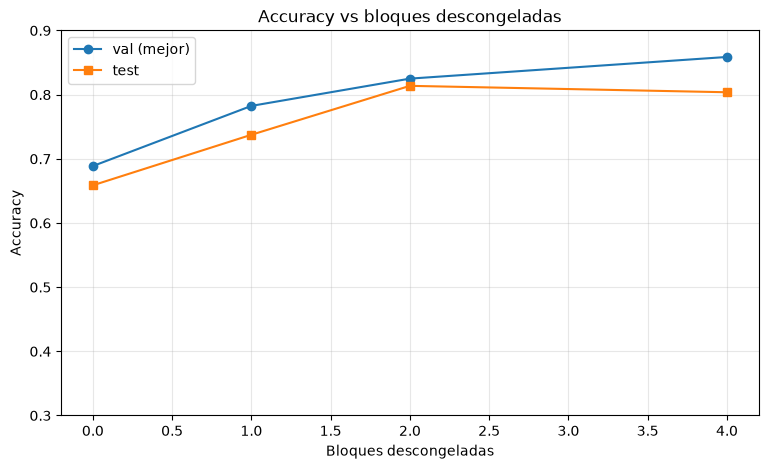

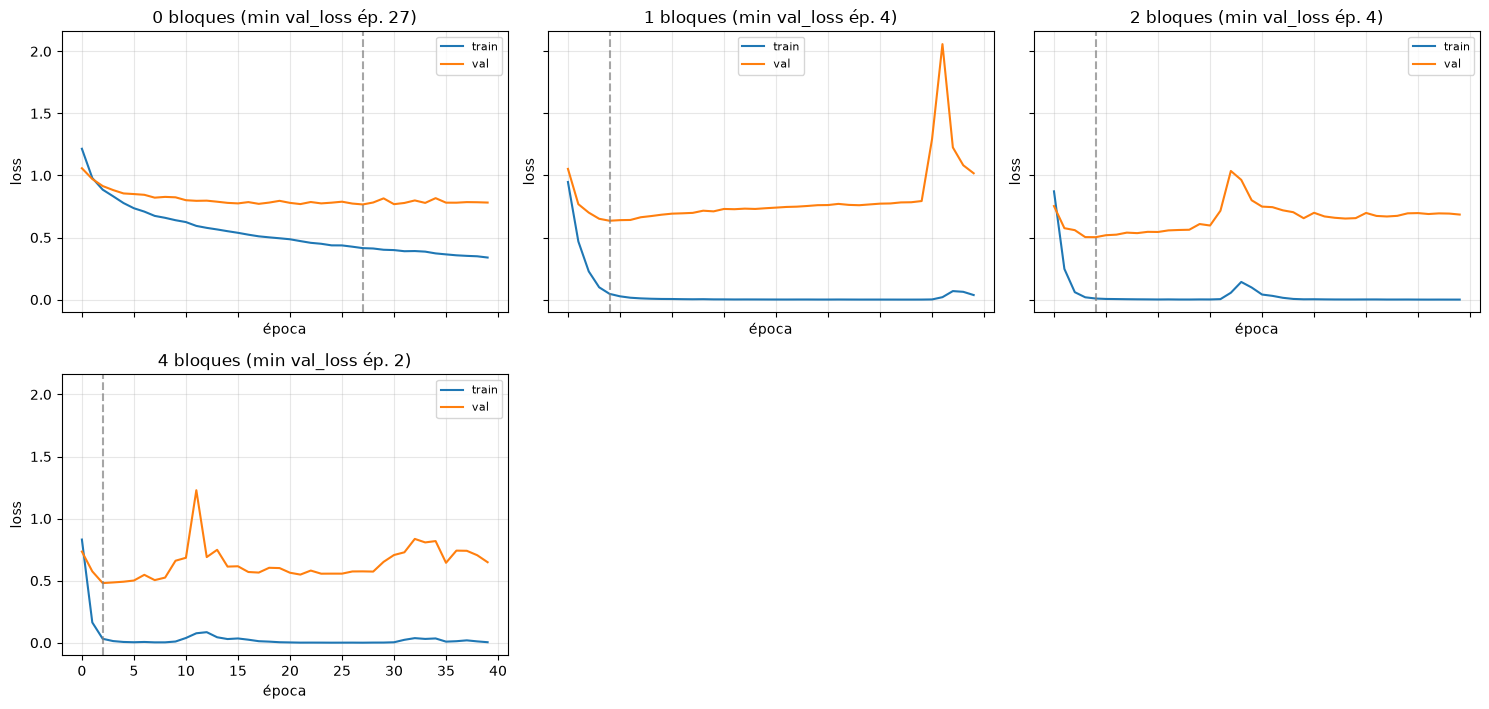

In [19]:
df_bloques = graficar_barrido(resultados_bloques, "bloques")

### Conclusiones sección 4.2

Los bloques inception tienen tamaños desparejos (saltan de ~9 a ~18 a ~24 capas de convolución). Esto resulta en que los parámetros de entrenamiento rápidamente llevan al sobreajuste (con tan solo un bloque ya hay ~6M de parámetros).

## **Sección 4.3: Tercer y último enfoque - descongelamiento por capas *convolucionales***
Para un barrido más **uniforme y fino**, acá descongelamos por **cantidad de capas convolucionales**:
cada paso agrega exactamente una `Conv2D` entrenable. Es la unidad que mejor controla la
capacidad del modelo y evita puntos repetidos (como el 0 == 10 capas de antes).

In [26]:
# Poné en True para RE-ENTRENAR (crea el siguiente índice, no pisa); False = carga si existe.
QUIERO_REENTRENAR_CONVS = False

In [27]:
# Verificación: cuántos params libera cada cantidad de convoluciones (para elegir CONFIGS_CONVS)
_base_chk = keras.applications.InceptionV3(include_top=False, weights="imagenet",
                                           input_shape=(299, 299, 3))
total_convs = sum(1 for l in _base_chk.layers if isinstance(l, keras.layers.Conv2D))
print("Total Conv2D en InceptionV3:", total_convs)
for nc in [0, 2, 4, 8, 16, 32]:
    ini = _inicio_ultimas_convs(_base_chk, nc)
    params = (sum(int(tf.size(w)) for l in _base_chk.layers[ini:]
                  if not isinstance(l, keras.layers.BatchNormalization)
                  for w in l.trainable_variables)) if nc > 0 else 8196
    print(f"{nc:2} convs -> arranca en capa {ini:3} | ~{params:,} params entrenables")

Total Conv2D en InceptionV3: 94
 0 convs -> arranca en capa 311 | ~8,196 params entrenables
 2 convs -> arranca en capa 294 | ~1,048,576 params entrenables
 4 convs -> arranca en capa 291 | ~1,933,312 params entrenables
 8 convs -> arranca en capa 283 | ~5,152,768 params entrenables
16 convs -> arranca en capa 253 | ~10,043,392 params entrenables
32 convs -> arranca en capa 203 | ~14,536,704 params entrenables


In [28]:
resultados_convs = []
CONFIGS_CONVS = [0, 2, 4, 8, 16]   # nº de convoluciones finales a descongelar
for n in CONFIGS_CONVS:
    base = f"exp1_convs_{n}"
    idxs = _indices_existentes(base)

    if idxs and not QUIERO_REENTRENAR_CONVS:
        ult = idxs[-1]
        print(f"\n[{n} convs] Ya existe {base}_{ult}.keras -> CARGANDO (no entreno).")
        model, history = cargar_modelo_y_historial(f"{base}_{ult}")
        r = resultado(model, history, n, test_ds)
    else:
        nuevo = (idxs[-1] + 1) if idxs else 1
        accion = "RE-ENTRENANDO" if idxs else "ENTRENANDO"
        print(f"\n[{n} convs] {accion} -> se guardará como {base}_{nuevo}")
        t0 = time.time()
        model, history = entrenar_config(n, train_ds, val_ds, modo="convs", usar_early_stopping=False)
        seg = round(time.time() - t0, 1)
        guardar_modelo_y_historial(model, history, f"{base}_{nuevo}")
        r = resultado(model, history, n, test_ds, segundos=seg)

    resultados_convs.append(r)
    del model
    keras.backend.clear_session()


[0 convs] Ya existe exp1_convs_0_2.keras -> CARGANDO (no entreno).
Entorno local detectado. Cargando archivos directamente desde el directorio de trabajo.
Modelo cargado exitosamente desde: models/exp1_convs_0_2.keras
Historial cargado exitosamente desde: histories/exp1_convs_0_2_history.pkl

[2 convs] Ya existe exp1_convs_2_1.keras -> CARGANDO (no entreno).
Entorno local detectado. Cargando archivos directamente desde el directorio de trabajo.
Modelo cargado exitosamente desde: models/exp1_convs_2_1.keras
Historial cargado exitosamente desde: histories/exp1_convs_2_1_history.pkl

[4 convs] Ya existe exp1_convs_4_1.keras -> CARGANDO (no entreno).
Entorno local detectado. Cargando archivos directamente desde el directorio de trabajo.
Modelo cargado exitosamente desde: models/exp1_convs_4_1.keras
Historial cargado exitosamente desde: histories/exp1_convs_4_1_history.pkl

[8 convs] Ya existe exp1_convs_8_1.keras -> CARGANDO (no entreno).
Entorno local detectado. Cargando archivos directa

### Resultados del barrido por convoluciones

,n_descongeladas,params_entrenables,best_val_acc,best_val_loss,epoca_min_val_loss,test_acc,test_loss,epocas_corridas,segundos
0,0,8196,0.69375,0.766066,27,0.65875,0.865635,40,None
1,2,1058820,0.76125,0.597349,13,0.76000,0.734299,40,None
2,4,1943556,0.77375,0.590582,9,0.73875,0.768298,40,None
3,8,5163780,0.78375,0.603086,5,0.76250,0.893371,40,None
4,16,10057668,0.81625,0.512497,3,0.79500,0.903218,40,None


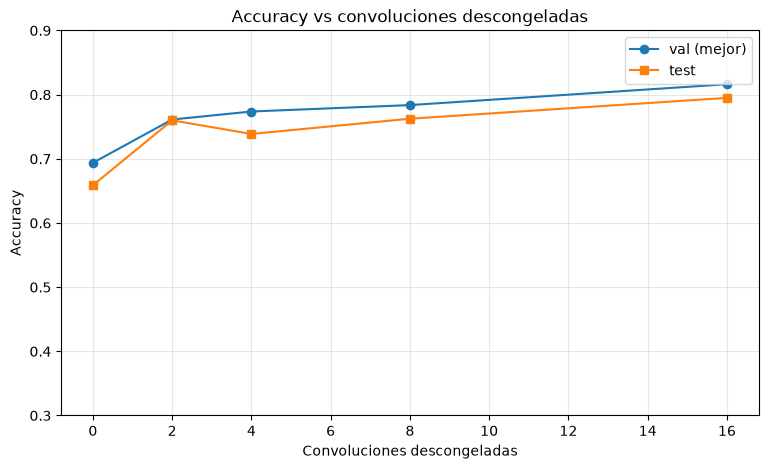

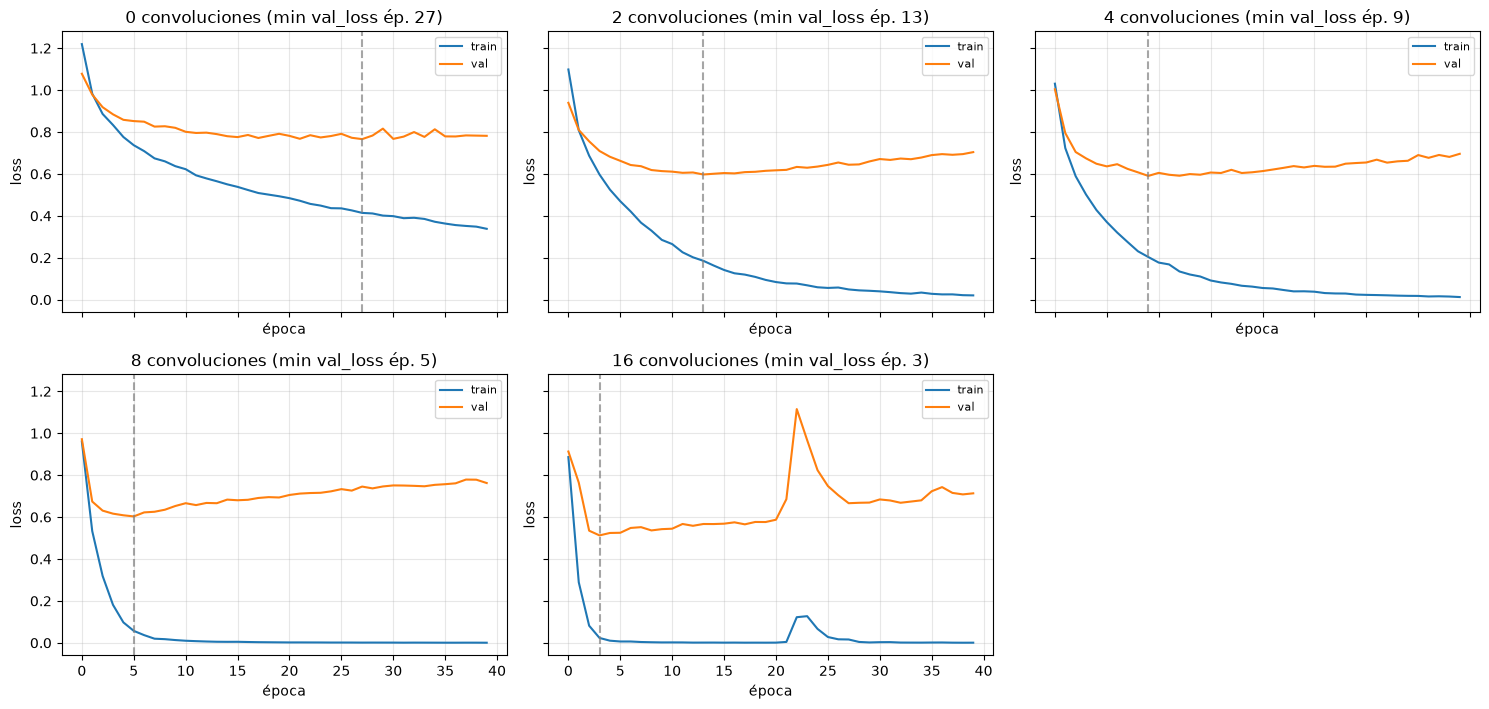

In [29]:
df_convs = graficar_barrido(resultados_convs, "convoluciones")

### Conclusiones sección 4.3

Vemos como los resultados hasta *n = 8* son relativamente inferiores en términos de accuracy a los obtenidos descongelando un bloque inception, lo que tiene sentido pues son significativamente (~1M menos) parámetros.  

Sin embargo, es una curva mucho más suave, que nos permite detectar mejor dónde empieza a aparecer el **sobreajuste**: la época de menor `val_loss` se corre de forma gradual (13 -> 9 -> 5 -> 3) a medida que liberamos más convoluciones, en lugar de caer de golpe a la época 1 como pasaba al descongelar por capas o por bloques.

Creemos que, usando técnicas como **data augmentation** y **dropout**, podemos subir estos valores sin que el sobreajuste se dispare.

**¿Por qué este enfoque es el mejor para nuestro modelo base?**

Usando el descongelamiento por capas convolucionales, cada paso agrega exactamente una `Conv2D` entrenable, por lo que los parámetros crecen de manera pareja (1.0M -> 1.9M -> 5.1M -> 10.0M) y no se repiten puntos (como el 0 == 10 del primer enfoque, ni los saltos desparejos de los bloques). 

Eso nos da una base correcta: podemos fijar una cantidad de convoluciones y variar una sola cosa por vez (dropout, data augmentation, tamaño del dataset) para medir su efecto real, que es justamente lo que haremos en el Experimento 2.

### Extra: Matriz de confusión por modelo

Para cada configuración, matriz de confusión sobre el set de *test* y reporte por clase.
Sirve para ver **qué emociones se confunden entre sí** (no solo la accuracy global).

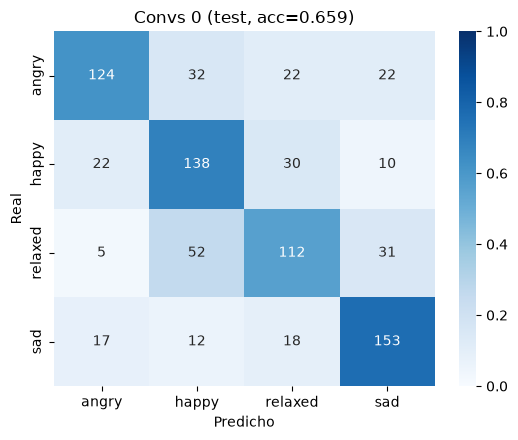

              precision    recall  f1-score   support

       angry      0.738     0.620     0.674       200
       happy      0.590     0.690     0.636       200
     relaxed      0.615     0.560     0.586       200
         sad      0.708     0.765     0.736       200

    accuracy                          0.659       800
   macro avg      0.663     0.659     0.658       800
weighted avg      0.663     0.659     0.658       800



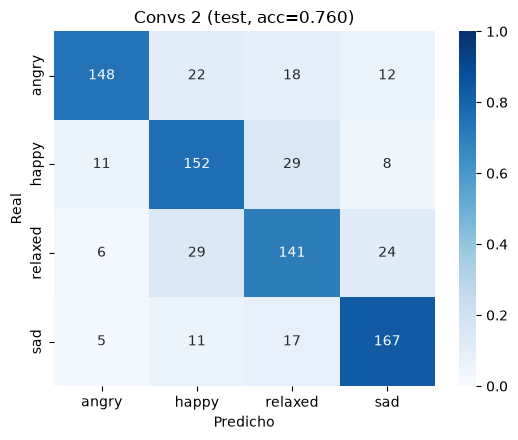

              precision    recall  f1-score   support

       angry      0.871     0.740     0.800       200
       happy      0.710     0.760     0.734       200
     relaxed      0.688     0.705     0.696       200
         sad      0.791     0.835     0.813       200

    accuracy                          0.760       800
   macro avg      0.765     0.760     0.761       800
weighted avg      0.765     0.760     0.761       800



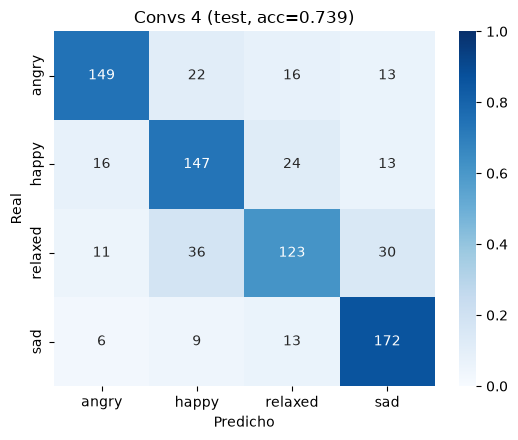

              precision    recall  f1-score   support

       angry      0.819     0.745     0.780       200
       happy      0.687     0.735     0.710       200
     relaxed      0.699     0.615     0.654       200
         sad      0.754     0.860     0.804       200

    accuracy                          0.739       800
   macro avg      0.740     0.739     0.737       800
weighted avg      0.740     0.739     0.737       800



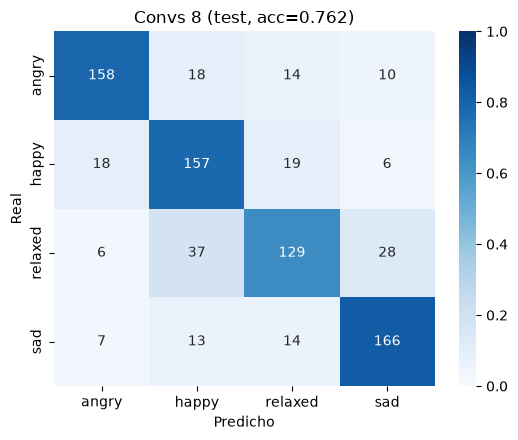

              precision    recall  f1-score   support

       angry      0.836     0.790     0.812       200
       happy      0.698     0.785     0.739       200
     relaxed      0.733     0.645     0.686       200
         sad      0.790     0.830     0.810       200

    accuracy                          0.762       800
   macro avg      0.764     0.763     0.762       800
weighted avg      0.764     0.762     0.762       800



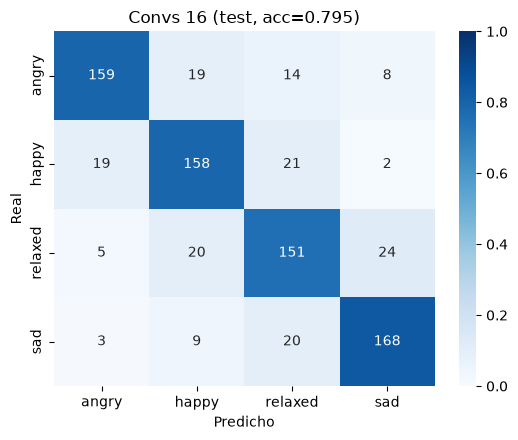

              precision    recall  f1-score   support

       angry      0.855     0.795     0.824       200
       happy      0.767     0.790     0.778       200
     relaxed      0.733     0.755     0.744       200
         sad      0.832     0.840     0.836       200

    accuracy                          0.795       800
   macro avg      0.797     0.795     0.795       800
weighted avg      0.797     0.795     0.795       800



In [30]:
# Matrices de confusión del barrido por convoluciones
for r in resultados_convs:
    plot_matriz_confusion(
        r["y_true"], r["y_pred"],
        f'Convs {r["n_descongeladas"]} (test, acc={r["test_acc"]:.3f})')

# **Sección 5: Utilizando el modelo base con distintas opciones**

A lo largo de la **Sección 4** buscamos la mejor forma de descongelar InceptionV3 y concluimos que el barrido por **capas convolucionales** es el más controlable. De ese barrido elegimos como **modelo base** el de **2 convoluciones descongeladas**, porque es el que mejor combina las dos cosas que nos importan:

- **Evita el sobreajuste:** su `val_loss` mínimo recién aparece en la época 13 (contra época 3 a 5 al descongelar más capas).
- **Buena precisión con pocos parámetros:** 0.760 de accuracy en test con solo ~1.06M de parámetros entrenables, prácticamente empatado con configuraciones de 5 a 10M.

Recordamos sus números del barrido de la sección 4.3:

| n convs | params | val_acc | época min val_loss |
|---|---|---|---|
| **2 (base)** | 1.06M | 0.761 | 13 |

Sobre esta base vamos a probar **distintas estrategias de regularización** (dropout, data augmentation y algo más de capacidad) y medir su efecto de forma robusta con **k-fold cross validation**, en lugar de un único split que es ruidoso.

> En la presentación del tp nos dijeron que podría llegar a ser muy fácil el problema, es decir que tengamos una muy buena acc con pocas capas descongeladas, consideramos que 76% (lo obtenido) no es el caso, y que podemos mejorarlo utilizando distintas estrategias, por ende suspendemos el experimento 2: reducir el dataset.


## 5.1 Estrategias a evaluar

Partimos del modelo base (2 convoluciones, sin regularización) y combinamos tres ejes:

- **Capacidad** (capas convolucionales descongeladas): `n = 2` (base) y `n = 8` (más capacidad).
- **Dropout** antes de la capa densa final: `0.0`, `0.2` y `0.5`.
- **Data augmentation** (flip / rotación / zoom al vuelo): activado o no.

No probamos la grilla completa (sería 2 x 3 x 2 = 12 combinaciones) sino una **lista curada** que va sumando regularización de a poco, para aislar qué aporta cada técnica:

| # | Estrategia | n convs | dropout | augment |
|---|---|---|---|---|
| 1 | base (sin reg) | 2 | 0.0 | no |
| 2 | + dropout 0.2 | 2 | 0.2 | no |
| 3 | + dropout 0.5 | 2 | 0.5 | no |
| 4 | + augment | 2 | 0.0 | sí |
| 5 | + dropout 0.2 + augment | 2 | 0.2 | sí |
| 6 | más capacidad + reg | 8 | 0.2 | sí |
| 7 | más capacidad + reg fuerte | 8 | 0.5 | sí |



## 5.2 Evaluación con K-Fold Cross Validation

Con un único split, la accuracy depende mucho de qué imágenes cayeron en validación. Para una estimación más **robusta** usamos **StratifiedKFold** (mantiene el balance de clases en cada fold): entrenamos `k = 5` modelos por estrategia, cada uno validando en un fold distinto, y reportamos **media ± desvío** de la accuracy y de la loss.

Además juntamos las predicciones **out-of-fold** (la predicción de cada imagen cuando le tocó estar en validación) de los 5 folds en una única matriz de confusión por estrategia, que cubre las 4000 imágenes sin fuga de información.

Usamos **early stopping** (monitoreando `val_accuracy`, paciencia 6) para cortar cada fold cuando deja de mejorar, y cacheamos los resultados en disco para no reentrenar al re-ejecutar el notebook.


In [8]:
# --- Utilidades de la Sección 5 (autocontenidas: no dependen de las celdas de Exp 2) ---
import os, time, pickle
from sklearn.model_selection import StratifiedKFold

def ds_desde_archivos(paths, labels, batch=BATCH, shuffle=False, seed=SEED):
    """tf.data desde una lista de archivos, con el preprocesado de InceptionV3."""
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(paths), seed=seed, reshuffle_each_iteration=True)
    def cargar(p, y):
        img = tf.io.read_file(p)
        img = tf.io.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, IMG_SIZE)
        img = preprocess_input(img)
        return img, y
    return ds.map(cargar, num_parallel_calls=AUTOTUNE).batch(batch).prefetch(AUTOTUNE)


def kfold_estrategia(paths, labels, *, n_convs, dropout, augment,
                     k=5, lr=None, epochs=40, patience=6, batch=BATCH,
                     usar_early_stopping=True, verbose=0):
    """Corre k-fold estratificado para UNA estrategia y promedia las métricas.

    Devuelve un dict con media ± desvío de accuracy y loss entre folds, y las
    predicciones out-of-fold concatenadas (para la matriz de confusión).
    """
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=SEED)
    accs, losses, yt_all, yp_all = [], [], [], []
    for fold, (tr, va) in enumerate(skf.split(paths, labels), 1):
        keras.backend.clear_session()
        lr_f = (1e-3 if n_convs == 0 else 1e-4) if lr is None else lr
        train_ds_f = ds_desde_archivos(paths[tr], labels[tr], batch=batch, shuffle=True)
        val_ds_f   = ds_desde_archivos(paths[va], labels[va], batch=batch)
        model = create_inception_model(num_classes=4, augment=augment,
                                       n_convs_descongeladas=n_convs, dropout=dropout)
        model.compile(optimizer=keras.optimizers.Adam(lr_f),
                      loss="sparse_categorical_crossentropy", metrics=["accuracy"])
        cb = []
        if usar_early_stopping:
            cb.append(keras.callbacks.EarlyStopping(monitor="val_accuracy",
                                                    patience=patience,
                                                    restore_best_weights=True))
        h = model.fit(train_ds_f, validation_data=val_ds_f,
                      epochs=epochs, callbacks=cb, verbose=verbose)
        accs.append(max(h.history["val_accuracy"]))
        losses.append(min(h.history["val_loss"]))
        yt, yp = predicciones(model, val_ds_f)
        yt_all.append(yt); yp_all.append(yp)
        print(f"    fold {fold}/{k}: val_acc={accs[-1]:.4f}  val_loss={losses[-1]:.4f}")
    return {
        "acc_media": float(np.mean(accs)),   "acc_std": float(np.std(accs)),
        "loss_media": float(np.mean(losses)), "loss_std": float(np.std(losses)),
        "accs": accs,
        "y_true": np.concatenate(yt_all), "y_pred": np.concatenate(yp_all),
    }


In [ ]:
# Poné en True para REENTRENAR; False = carga el .pkl si existe (no reentrena).
QUIERO_REENTRENAR_ESTRATEGIAS = False
RUTA_ESTRATEGIAS = "histories/resultados_estrategias.pkl"
K_FOLDS = 5

ESTRATEGIAS = [
    ("base (n=2, sin reg)",         dict(n_convs=2, dropout=0.0, augment=False)),
    ("n=2 + dropout 0.2",           dict(n_convs=2, dropout=0.2, augment=False)),
    ("n=2 + dropout 0.5",           dict(n_convs=2, dropout=0.5, augment=False)),
    ("n=2 + augment",               dict(n_convs=2, dropout=0.0, augment=True)),
    ("n=2 + dropout 0.2 + augment", dict(n_convs=2, dropout=0.2, augment=True)),
    ("n=8 + dropout 0.2 + augment", dict(n_convs=8, dropout=0.2, augment=True)),
    ("n=8 + dropout 0.5 + augment", dict(n_convs=8, dropout=0.5, augment=True)),
]

if os.path.exists(RUTA_ESTRATEGIAS) and not QUIERO_REENTRENAR_ESTRATEGIAS:
    with open(RUTA_ESTRATEGIAS, "rb") as f:
        resultados_estrategias = pickle.load(f)
    print(f"Cargado {RUTA_ESTRATEGIAS} ({len(resultados_estrategias)} estrategias) -> no reentreno.")
else:
    #  correr el barrido completo.
    resultados_estrategias = []                      # acá se acumulan los resultados

    # Recorremos cada estrategia de la lista.
    for nombre, cfg in ESTRATEGIAS:

        print(f"\n== {nombre} | {K_FOLDS}-fold sobre {len(paths_all)} imágenes ==")
        t0 = time.time()

        #entrena K_FOLDS modelos (uno por fold) y promedia.
        # **cfg desempaqueta el dict -> n_convs=..., dropout=..., augment=...
        # Devuelve un dict con acc_media, acc_std, loss_media, loss_std y las
        # predicciones out-of-fold (y_true, y_pred).
        m = kfold_estrategia(paths_all, labels_all, k=K_FOLDS, **cfg)

        # Le agregamos al resultado: el nombre, cuánto tardó, y los propios
        # hiperparámetros (para tenerlos como columnas en la tabla final).
        m.update({"estrategia": nombre, "segundos": round(time.time() - t0, 1), **cfg})

        print(f"   => acc = {m['acc_media']:.4f} ± {m['acc_std']:.4f} | "
              f"loss = {m['loss_media']:.4f} ± {m['loss_std']:.4f}")

        resultados_estrategias.append(m)

    os.makedirs("histories", exist_ok=True)
    with open(RUTA_ESTRATEGIAS, "wb") as f:
        pickle.dump(resultados_estrategias, f)
    print(f"\nGuardado en {RUTA_ESTRATEGIAS}")



Cargado histories/resultados_estrategias.pkl (7 estrategias) -> no reentreno.


In [10]:
# --- Tabla resumen -----------------------------------------------------------
# Pasamos la lista de dicts a un DataFrame, descartando los campos pesados o
# no tabulares (arrays de predicciones y la lista de accuracies por fold).
df_estrategias = pd.DataFrame([{k: v for k, v in r.items()
                                if k not in ("y_true", "y_pred", "accs")}
                               for r in resultados_estrategias])

# Ordenamos de mayor a menor accuracy media (la mejor estrategia queda arriba)
# y renumeramos las filas desde 0.
df_estrategias = (df_estrategias
                  .sort_values("acc_media", ascending=False)
                  .reset_index(drop=True))

 # última línea suelta: Jupyter la muestra como tabla
df_estrategias

,acc_media,acc_std,loss_media,loss_std,estrategia,segundos,n_convs,dropout,augment
0,0.80300,0.015764,0.587860,0.036206,n=8 + dropout 0.5 + augment,1335.4,8,0.5,True
1,0.80025,0.011710,0.573418,0.039183,n=8 + dropout 0.2 + augment,886.6,8,0.2,True
2,0.78225,0.018156,0.572874,0.027825,n=2 + augment,1253.8,2,0.0,True
3,0.77925,0.017403,0.576787,0.028891,n=2 + dropout 0.2 + augment,1211.7,2,0.2,True
4,0.77750,0.014642,0.584675,0.021226,n=2 + dropout 0.2,727.4,2,0.2,False
5,0.77625,0.017176,0.585152,0.027330,"base (n=2, sin reg)",654.9,2,0.0,False
6,0.77500,0.016808,0.585399,0.024327,n=2 + dropout 0.5,832.9,2,0.5,False


### 5.2.1: Guardar el mejor modelo de la mejor estrategia

El k-fold nos dice qué estrategia **promedia** mejor, pero descarta los modelos entrenados.
Acá re-entrenamos la estrategia ganadora y nos quedamos con el modelo del **mejor fold**
(el de mayor `val_accuracy`), que guardamos a disco.

Elegimos entonces, como mejor estrategia, la de $ id = 1 $, en base a los resultados de accuracy (muy similares al número 0 que fue el mejor) y al tiempo de ejecución.

- `ELEGIR_RANKING`: qué fila de `df_estrategias` usar (0 = mejor accuracy; 1 = segunda —
  a veces casi empatada con la primera pero más rápida / con menor loss).
- `QUIERO_REENTRENAR_MEJOR`: en `False` carga el modelo ya guardado en vez de re-entrenar.

In [ ]:
# --- Guardar el MEJOR modelo de la MEJOR estrategia --------------------------
from sklearn.model_selection import StratifiedKFold

ELEGIR_RANKING = 1               # 0 = mejor acc_media ; 1 = segunda (a veces casi empate)
QUIERO_REENTRENAR_MEJOR = False   # False = carga el guardado si existe (no re-entrena)

elegida = df_estrategias.iloc[ELEGIR_RANKING]
cfg = dict(n_convs=int(elegida["n_convs"]),
           dropout=float(elegida["dropout"]),
           augment=bool(elegida["augment"]))
print(f"Estrategia elegida: {elegida['estrategia']} | acc_media={elegida['acc_media']:.4f}")
print("Config:", cfg)

base_name = "mejor_estrategia"
idxs = _indices_existentes(base_name)

if idxs and not QUIERO_REENTRENAR_MEJOR:
    modelo_final, hist_final = cargar_modelo_y_historial(f"{base_name}_{idxs[-1]}")
    print(f"Cargado {base_name}_{idxs[-1]} (no re-entreno).")
else:
    nuevo = (idxs[-1] + 1) if idxs else 1
    skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
    best_acc = -1.0
    for fold, (tr, va) in enumerate(skf.split(paths_all, labels_all), 1):
        keras.backend.clear_session()
        lr_f = 1e-3 if cfg["n_convs"] == 0 else 1e-4 
        train_f = ds_desde_archivos(paths_all[tr], labels_all[tr], shuffle=True)
        val_f   = ds_desde_archivos(paths_all[va], labels_all[va])
        model = create_inception_model(num_classes=4, augment=cfg["augment"],
                                       n_convs_descongeladas=cfg["n_convs"], dropout=cfg["dropout"])
        model.compile(optimizer=keras.optimizers.Adam(lr_f),
                      loss="sparse_categorical_crossentropy", metrics=["accuracy"])
        cb = [keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=6,
                                            restore_best_weights=True)]
        h = model.fit(train_f, validation_data=val_f, epochs=40, callbacks=cb, verbose=0)
        acc = max(h.history["val_accuracy"])
        if acc > best_acc:                      # nuevo mejor fold -> lo guardo (pisa el anterior)
            best_acc = acc
            guardar_modelo_y_historial(model, h.history, f"{base_name}_{nuevo}")
            print(f"  fold {fold}/{K_FOLDS}: val_acc={acc:.4f}  <- nuevo mejor (guardado)")
        else:
            print(f"  fold {fold}/{K_FOLDS}: val_acc={acc:.4f}")
        del model
    print(f"\nMejor fold: val_acc={best_acc:.4f} -> models/{base_name}_{nuevo}.keras")
    modelo_final, hist_final = cargar_modelo_y_historial(f"{base_name}_{nuevo}")

Estrategia elegida: n=8 + dropout 0.2 + augment | acc_media=0.8003
Config: {'n_convs': 8, 'dropout': 0.2, 'augment': True}


/home/bussa/venvs/tp-final/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Modelo guardado exitosamente en: models/mejor_estrategia_2.keras
Historial guardado exitosamente en: histories/mejor_estrategia_2_history.pkl
Entorno local detectado. Los archivos permanecen guardados en el disco local.
  fold 1/5: val_acc=0.7775  <- nuevo mejor (guardado)
Modelo guardado exitosamente en: models/mejor_estrategia_2.keras
Historial guardado exitosamente en: histories/mejor_estrategia_2_history.pkl
Entorno local detectado. Los archivos permanecen guardados en el disco local.
  fold 2/5: val_acc=0.8012  <- nuevo mejor (guardado)
  fold 3/5: val_acc=0.7862
Modelo guardado exitosamente en: models/mejor_estrategia_2.keras
Historial guardado exitosamente en: histories/mejor_estrategia_2_history.pkl
Entorno local detectado. Los archivos permanecen guardados en el disco local.
  fold 4/5: val_acc=0.8100  <- nuevo mejor (guardado)
  fold 5/5: val_acc=0.8050

Mejor fold: val_acc=0.8100 -> models/mejor_estrategia_2.keras
Entorno local detectado. Cargando archivos directamente desde

### ¿El mejor modelo sobreajusta?

Cargamos el mejor modelo guardado (`mejor_estrategia`) junto con su historial y graficamos
las curvas **train vs validación** (loss y accuracy) para ver si sobreajusta y en qué época.

Entorno local detectado. Cargando archivos directamente desde el directorio de trabajo.
Modelo cargado exitosamente desde: models/mejor_estrategia_2.keras
Historial cargado exitosamente desde: histories/mejor_estrategia_2_history.pkl


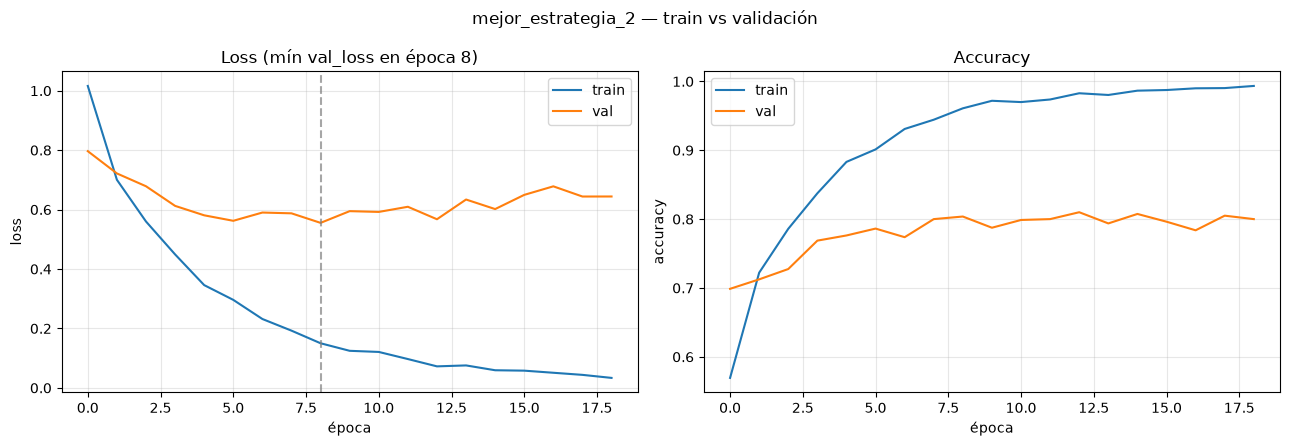

Épocas corridas: 19 | mejor val_loss en época 8
Gap final train-val accuracy: 0.193  (un gap > 0.10 sugiere sobreajuste)


In [15]:
# Cargar el mejor modelo + su historial y ver si sobreajusta
base_name = "mejor_estrategia"
idxs = _indices_existentes(base_name)

if not idxs:
    print("No hay 'mejor_estrategia' guardado todavía. Corré antes la celda "
          "'Guardar el mejor modelo de la mejor estrategia'.")
else:
    ult = idxs[-1]
    modelo_final, hist_final = cargar_modelo_y_historial(f"{base_name}_{ult}")

    fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
    # Loss
    ax[0].plot(hist_final["loss"], label="train")
    ax[0].plot(hist_final["val_loss"], label="val")
    mejor_ep = int(np.argmin(hist_final["val_loss"]))
    ax[0].axvline(mejor_ep, ls="--", c="gray", alpha=.7)
    ax[0].set_title(f"Loss (mín val_loss en época {mejor_ep})")
    ax[0].set_xlabel("época"); ax[0].set_ylabel("loss"); ax[0].grid(alpha=.3); ax[0].legend()
    # Accuracy
    ax[1].plot(hist_final["accuracy"], label="train")
    ax[1].plot(hist_final["val_accuracy"], label="val")
    ax[1].set_title("Accuracy"); ax[1].set_xlabel("época"); ax[1].set_ylabel("accuracy")
    ax[1].grid(alpha=.3); ax[1].legend()
    plt.suptitle(f"{base_name}_{ult} — train vs validación")
    plt.tight_layout(); plt.show()

    # Diagnóstico simple
    gap = hist_final["accuracy"][-1] - hist_final["val_accuracy"][-1]
    print(f"Épocas corridas: {len(hist_final['loss'])} | mejor val_loss en época {mejor_ep}")
    print(f"Gap final train-val accuracy: {gap:.3f}  (un gap > 0.10 sugiere sobreajuste)")

## 5.3 Resultados

Comparamos las estrategias por su accuracy media entre folds (con el desvío como barra de error) y mostramos la matriz de confusión out-of-fold de la mejor, junto con su reporte de precision / recall / f1 por clase.


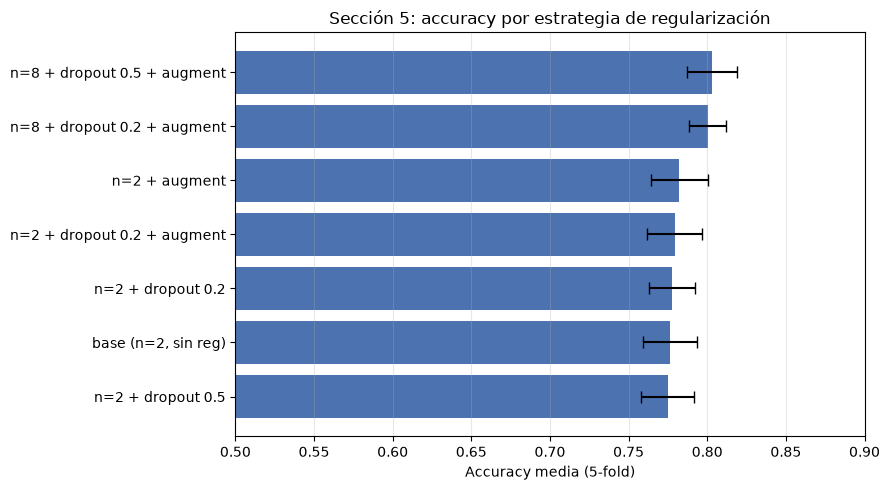

In [33]:
# Accuracy media ± desvío por estrategia (de peor a mejor)
orden = df_estrategias.sort_values("acc_media")
plt.figure(figsize=(9, 5))
plt.barh(orden["estrategia"], orden["acc_media"],
         xerr=orden["acc_std"], capsize=4, color="#4C72B0")
plt.xlabel(f"Accuracy media ({K_FOLDS}-fold)")
plt.xlim(0.5, 0.9)
plt.title("Sección 5: accuracy por estrategia de regularización")
plt.grid(axis="x", alpha=.3)
plt.tight_layout(); plt.show()


Mejor estrategia: n=8 + dropout 0.5 + augment  (acc 0.803 ± 0.016)



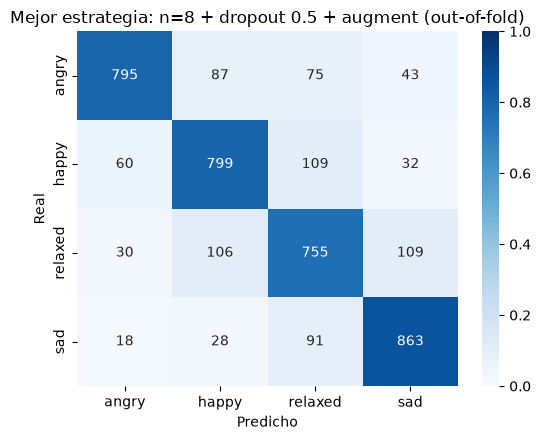

              precision    recall  f1-score   support

       angry      0.880     0.795     0.836      1000
       happy      0.783     0.799     0.791      1000
     relaxed      0.733     0.755     0.744      1000
         sad      0.824     0.863     0.843      1000

    accuracy                          0.803      4000
   macro avg      0.805     0.803     0.803      4000
weighted avg      0.805     0.803     0.803      4000



In [34]:
# Matriz de confusión out-of-fold de la MEJOR estrategia (+ classification_report)
mejor = max(resultados_estrategias, key=lambda r: r["acc_media"])
print(f"Mejor estrategia: {mejor['estrategia']}  "
      f"(acc {mejor['acc_media']:.3f} ± {mejor['acc_std']:.3f})\n")
plot_matriz_confusion(mejor["y_true"], mejor["y_pred"],
                      f"Mejor estrategia: {mejor['estrategia']} (out-of-fold)")


## Conclusiones sección 5

Cómo mencionamos anteriormente, elegimos usar el modelo con configuración:
- $n = 8$
- $dropout = 0.2 $
- uso de data augmentation

Con el que obtuvimos como resultado $val_acc = 0.81$, verifiquemos entonces nuestro $ test_acc $, esperando que sea similar a los resultados sobre la validación.